In [1]:
# ── Imports ────────────────────────────────────────────
import warnings
from pathlib import Path
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

# ── Load data ──────────────────────────────────────────
df = pd.read_parquet("../data/retail_clean.parquet")
df["invoicedate"] = pd.to_datetime(df["invoicedate"])
segments = pd.read_parquet("../data/segments.parquet")

print(f"Transactions: {len(df):,}")
print(f"Customers   : {df['customer_id'].nunique():,}")
print(f"Date range  : {df['invoicedate'].min()} → {df['invoicedate'].max()}")

Transactions: 779,425
Customers   : 5,878
Date range  : 2009-12-01 07:45:00 → 2011-12-09 12:50:00


In [2]:
# ══════════════════════════════════════════════════════════
# CHURN DEFINITION
# ══════════════════════════════════════════════════════════
# Split data into two periods:
#   OBSERVATION period → build features from this
#   OUTCOME period     → define churn label from this
#
# Timeline:
#   |-------- observation --------|--- outcome (90 days) ---|
#   2009-12-01              cutoff_date              data_end
#
# Churn = customer who purchased during observation
#         but did NOT purchase during outcome period
# ══════════════════════════════════════════════════════════

data_end    = df["invoicedate"].max()
cutoff_date = data_end - timedelta(days=90)

print(f"Observation period : 2009-12-01 → {cutoff_date.date()}")
print(f"Outcome period     : {cutoff_date.date()} → {data_end.date()}")

# Split transactions
df_observe = df[df["invoicedate"] <= cutoff_date].copy()
df_outcome = df[df["invoicedate"] >  cutoff_date].copy()

print(f"\nObservation rows   : {len(df_observe):,}")
print(f"Outcome rows       : {len(df_outcome):,}")

# Customers who purchased in observation period
observe_customers = set(df_observe["customer_id"].unique())

# Customers who purchased in outcome period
outcome_customers = set(df_outcome["customer_id"].unique())

# Churn label: was in observation but NOT in outcome
churn_labels = pd.DataFrame({"customer_id": list(observe_customers)})
churn_labels["churned"] = churn_labels["customer_id"].apply(
    lambda x: 0 if x in outcome_customers else 1
)

print(f"\nTotal customers    : {len(churn_labels):,}")
print(f"Churned            : {churn_labels['churned'].sum():,} ({100*churn_labels['churned'].mean():.1f}%)")
print(f"Retained           : {(1 - churn_labels['churned']).sum():,} ({100*(1-churn_labels['churned'].mean()):.1f}%)")

Observation period : 2009-12-01 → 2011-09-10
Outcome period     : 2011-09-10 → 2011-12-09

Observation rows   : 620,572
Outcome rows       : 158,853

Total customers    : 5,281
Churned            : 2,989 (56.6%)
Retained           : 2,292 (43.4%)


In [3]:
# ══════════════════════════════════════════════════════════
# FEATURE ENGINEERING — using ONLY observation period data
# This prevents data leakage from the future
# ══════════════════════════════════════════════════════════

reference_date = cutoff_date

features = (
    df_observe.groupby("customer_id")
    .agg(
        # ── RFM ────────────────────────────────────────
        recency=("invoicedate",
                 lambda x: (reference_date - x.max()).days),
        frequency=("invoice", "nunique"),
        monetary=("revenue", "sum"),

        # ── Behavioural ────────────────────────────────
        avg_order_value=("revenue", "mean"),
        avg_quantity=("quantity", "mean"),
        unique_products=("stockcode", "nunique"),
        total_items=("quantity", "sum"),

        # ── Time patterns ─────────────────────────────
        tenure_days=("invoicedate",
                     lambda x: (x.max() - x.min()).days),
        first_purchase=("invoicedate", "min"),
        last_purchase=("invoicedate", "max"),
        total_orders=("invoice", "nunique"),

        # ── Geography ─────────────────────────────────
        is_uk=("is_uk", "first"),
        country=("country", "first"),
    )
    .reset_index()
)

# ── Derived features ──────────────────────────────────
# Average days between orders
features["avg_days_between_orders"] = np.where(
    features["total_orders"] > 1,
    features["tenure_days"] / (features["total_orders"] - 1),
    0  # single-order customers
)

# Revenue per product (spending concentration)
features["revenue_per_product"] = (
    features["monetary"] / features["unique_products"].clip(lower=1)
)

# Items per order
features["items_per_order"] = (
    features["total_items"] / features["total_orders"].clip(lower=1)
)

# Log transforms for skewed features
features["monetary_log"]  = np.log1p(features["monetary"])
features["frequency_log"] = np.log1p(features["frequency"])

# Drop date columns (not features)
features = features.drop(columns=["first_purchase", "last_purchase"])

# ── Merge with churn labels ───────────────────────────
model_df = features.merge(churn_labels, on="customer_id", how="inner")

# ── Merge segment from Weekend 3 ─────────────────────
model_df = model_df.merge(
    segments[["customer_id", "segment_name"]],
    on="customer_id",
    how="left"
)
model_df["segment_name"] = model_df["segment_name"].fillna("Unknown")

print(f"Model dataset shape: {model_df.shape}")
print(f"\n── Feature list ────────────────────────────────")
print(model_df.columns.tolist())
print(f"\n── Class balance ───────────────────────────────")
print(model_df["churned"].value_counts(normalize=True).round(3))

Model dataset shape: (5281, 19)

── Feature list ────────────────────────────────
['customer_id', 'recency', 'frequency', 'monetary', 'avg_order_value', 'avg_quantity', 'unique_products', 'total_items', 'tenure_days', 'total_orders', 'is_uk', 'country', 'avg_days_between_orders', 'revenue_per_product', 'items_per_order', 'monetary_log', 'frequency_log', 'churned', 'segment_name']

── Class balance ───────────────────────────────
churned
1    0.566
0    0.434
Name: proportion, dtype: float64


In [4]:
# ══════════════════════════════════════════════════════════
# TIME-AWARE SPLIT
# We do NOT use random split — that would leak future patterns.
# Instead we split by customer recency to simulate real deployment:
#   Train: 70% | Validation: 15% | Test: 15%
#   Sorted by recency so train has "older" patterns
# ══════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

# Define feature columns and target
exclude_cols = ["customer_id", "churned", "country", "segment_name"]
numeric_features = [c for c in model_df.columns
                    if c not in exclude_cols
                    and model_df[c].dtype in ["int64", "float64", "Int64"]]
categorical_features = ["segment_name"]

print(f"Numeric features    : {len(numeric_features)}")
print(f"Categorical features: {categorical_features}")

X = model_df[numeric_features + categorical_features]
y = model_df["churned"]

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 50/50 of temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\n── Split sizes ─────────────────────────────────")
print(f"Train : {len(X_train):,} ({100*len(X_train)/len(X):.0f}%)")
print(f"Val   : {len(X_val):,} ({100*len(X_val)/len(X):.0f}%)")
print(f"Test  : {len(X_test):,} ({100*len(X_test)/len(X):.0f}%)")
print(f"\n── Churn rate per split ─────────────────────────")
print(f"Train : {y_train.mean():.3f}")
print(f"Val   : {y_val.mean():.3f}")
print(f"Test  : {y_test.mean():.3f}")

Numeric features    : 14
Categorical features: ['segment_name']

── Split sizes ─────────────────────────────────
Train : 3,696 (70%)
Val   : 792 (15%)
Test  : 793 (15%)

── Churn rate per split ─────────────────────────
Train : 0.566
Val   : 0.566
Test  : 0.566


In [5]:
# ══════════════════════════════════════════════════════════
# SKLEARN PIPELINE
# ColumnTransformer handles numeric and categorical features
# separately — preventing leakage and ensuring clean code
# ══════════════════════════════════════════════════════════

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler",  StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("encoder", OneHotEncoder(drop="first", sparse_output=False,
                                          handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

# Full pipeline: preprocess → model
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",   # handles imbalanced classes
    )),
])

# Train
lr_pipeline.fit(X_train, y_train)

# Predict probabilities
y_train_prob = lr_pipeline.predict_proba(X_train)[:, 1]
y_val_prob   = lr_pipeline.predict_proba(X_val)[:, 1]
y_test_prob  = lr_pipeline.predict_proba(X_test)[:, 1]

# Predict classes
y_train_pred = lr_pipeline.predict(X_train)
y_val_pred   = lr_pipeline.predict(X_val)

print("Model trained successfully!")
print(f"\n── Training Metrics ────────────────────────────")
print(f"ROC-AUC (train): {roc_auc_score(y_train, y_train_prob):.4f}")
print(f"ROC-AUC (val)  : {roc_auc_score(y_val, y_val_prob):.4f}")
print(f"\n── Validation Classification Report ─────────────")
print(classification_report(y_val, y_val_pred, target_names=["Retained", "Churned"]))

Model trained successfully!

── Training Metrics ────────────────────────────
ROC-AUC (train): 0.8998
ROC-AUC (val)  : 0.9046

── Validation Classification Report ─────────────
              precision    recall  f1-score   support

    Retained       0.71      0.92      0.80       344
     Churned       0.92      0.71      0.80       448

    accuracy                           0.80       792
   macro avg       0.82      0.82      0.80       792
weighted avg       0.83      0.80      0.80       792



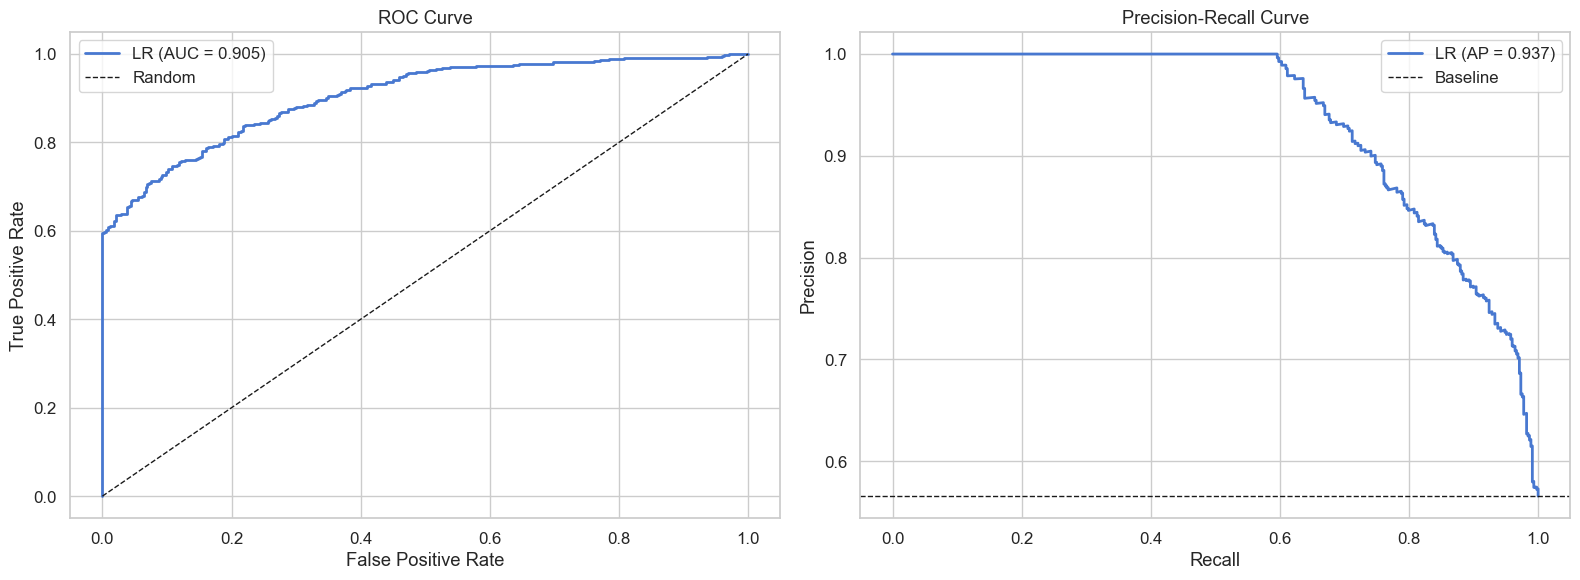

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── ROC Curve ──────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
auc_score   = roc_auc_score(y_val, y_val_prob)

axes[0].plot(fpr, tpr, linewidth=2, label=f"LR (AUC = {auc_score:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

# ── Precision-Recall Curve ─────────────────────────────
precision, recall, _ = precision_recall_curve(y_val, y_val_prob)
ap_score = average_precision_score(y_val, y_val_prob)

axes[1].plot(recall, precision, linewidth=2, label=f"LR (AP = {ap_score:.3f})")
axes[1].axhline(y=y_val.mean(), color="k", ls="--", linewidth=1, label="Baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/07_roc_pr_baseline.png", dpi=150)
plt.show()

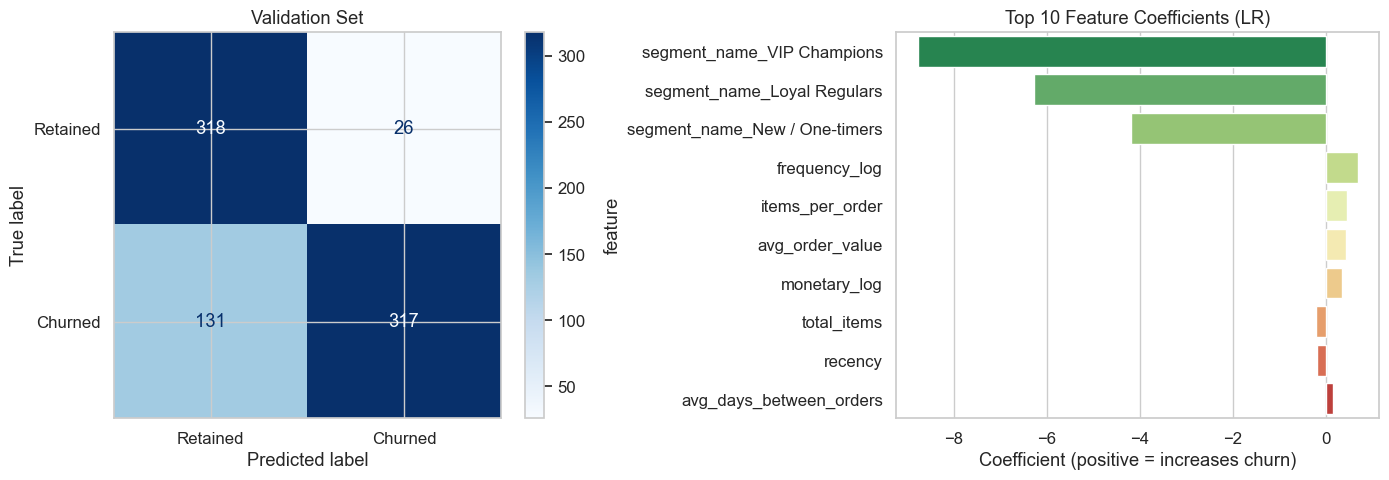

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred,
    display_labels=["Retained", "Churned"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_title("Validation Set")

# Feature importance (LR coefficients)
feature_names = (
    numeric_features
    + lr_pipeline.named_steps["preprocessor"]
      .transformers_[1][1]
      .named_steps["encoder"]
      .get_feature_names_out(categorical_features)
      .tolist()
)
coefs = lr_pipeline.named_steps["classifier"].coef_[0]

importance_df = (
    pd.DataFrame({"feature": feature_names, "coef": coefs})
    .assign(abs_coef=lambda x: x["coef"].abs())
    .sort_values("abs_coef", ascending=False)
    .head(10)
)

sns.barplot(
    data=importance_df, x="coef", y="feature",
    palette="RdYlGn_r", ax=axes[1]
)
axes[1].set_title("Top 10 Feature Coefficients (LR)")
axes[1].set_xlabel("Coefficient (positive = increases churn)")

plt.tight_layout()
plt.savefig("../reports/08_confusion_coefficients.png", dpi=150)
plt.show()

In [8]:
import joblib

# ── Save model ─────────────────────────────────────────
model_path = Path("../models")
model_path.mkdir(exist_ok=True)
joblib.dump(lr_pipeline, model_path / "churn_baseline_lr.pkl")
print(f"Model saved → {model_path / 'churn_baseline_lr.pkl'}")

# ── Save metrics report ───────────────────────────────
metrics = {
    "model": "Logistic Regression",
    "class_weight": "balanced",
    "roc_auc_train": round(roc_auc_score(y_train, y_train_prob), 4),
    "roc_auc_val": round(roc_auc_score(y_val, y_val_prob), 4),
    "avg_precision_val": round(ap_score, 4),
    "f1_val": round(f1_score(y_val, y_val_pred), 4),
    "accuracy_val": round(accuracy_score(y_val, y_val_pred), 4),
}

report = "# Churn Model — Baseline Report\n\n"
report += "## Logistic Regression (baseline)\n\n"
for k, v in metrics.items():
    report += f"- **{k}**: {v}\n"
report += f"\n## Classification Report (Validation)\n\n"
report += "```\n"
report += classification_report(y_val, y_val_pred, target_names=["Retained", "Churned"])
report += "```\n"

with open("../reports/churn_baseline.md", "w") as f:
    f.write(report)

print("Report saved → reports/churn_baseline.md")
print(f"\n── Summary ─────────────────────────────────────")
for k, v in metrics.items():
    print(f"  {k:25s}: {v}")

Model saved → ..\models\churn_baseline_lr.pkl
Report saved → reports/churn_baseline.md

── Summary ─────────────────────────────────────
  model                    : Logistic Regression
  class_weight             : balanced
  roc_auc_train            : 0.8998
  roc_auc_val              : 0.9046
  avg_precision_val        : 0.9367
  f1_val                   : 0.8015
  accuracy_val             : 0.8018
